# 十分钟入门pandas

In [69]:
#coding:utf8
%matplotlib inline

这个一篇针对pandas新手的简短入门，想要了解更多复杂的内容，参阅[*Cookbook*](http://pandas.pydata.org/pandas-docs/stable/cookbook.html#cookbook)

通常，我们首先要导入以下几个库：

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 创建对象

通过传递一个list来创建**Series**，pandas会默认创建整型索引：

In [71]:
s = pd.Series([1,3,5,np.nan,6,8])
s

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

通过传递一个numpy array，日期索引以及列标签来创建一个**DataFrame**：

In [72]:
dates = pd.date_range('20130101', periods=6)
dates

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [73]:
df = pd.DataFrame(np.random.randn(6,4), index=dates, columns=list('ABCD'))
df

,A,B,C,D
2013-01-01,1.295935,0.187139,1.687508,-1.186975
2013-01-02,0.073941,2.036332,2.096731,1.320487
2013-01-03,-1.480254,-0.313389,1.434660,0.373673
2013-01-04,1.249792,-0.162224,-1.943997,-0.317592
2013-01-05,-1.933881,-0.465019,1.534471,1.006916
2013-01-06,-1.572975,-0.329988,-1.385076,-0.021455


通过传递一个能够被转换为类似series的dict对象来创建一个**DataFrame**:

In [74]:
df2 = pd.DataFrame({ 'A' : 1.,
                     'B' : pd.Timestamp('20130102'),
                     'C' : pd.Series(1,index=list(range(4)),dtype='float32'),
                     'D' : np.array([3]*4,dtype='int32'),
                     'E' : pd.Categorical(["test","train","test","train"]),
                     'F' : 'foo' })
df2

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


可以看到各列的数据类型为：

In [75]:
df2.dtypes

A          float64
B    datetime64[s]
C          float32
D            int32
E         category
F           object
dtype: object

# 查看数据

查看frame中头部和尾部的几行：

In [76]:
df.head()

,A,B,C,D
2013-01-01,1.295935,0.187139,1.687508,-1.186975
2013-01-02,0.073941,2.036332,2.096731,1.320487
2013-01-03,-1.480254,-0.313389,1.434660,0.373673
2013-01-04,1.249792,-0.162224,-1.943997,-0.317592
2013-01-05,-1.933881,-0.465019,1.534471,1.006916


In [77]:
df.tail(3)

,A,B,C,D
2013-01-04,1.249792,-0.162224,-1.943997,-0.317592
2013-01-05,-1.933881,-0.465019,1.534471,1.006916
2013-01-06,-1.572975,-0.329988,-1.385076,-0.021455


显示索引、列名以及底层的numpy数据

In [78]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [79]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

In [80]:
df.values

array([[ 1.29593498,  0.18713917,  1.68750832, -1.18697497],
       [ 0.07394072,  2.03633164,  2.09673091,  1.32048691],
       [-1.48025409, -0.3133895 ,  1.43466009,  0.37367285],
       [ 1.24979179, -0.16222397, -1.94399683, -0.31759207],
       [-1.93388149, -0.46501899,  1.53447133,  1.00691621],
       [-1.57297481, -0.32998849, -1.38507636, -0.02145494]])

describe()能对数据做一个快速统计汇总

In [81]:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,-0.394574,0.158808,0.570716,0.195842
std,1.464108,0.946574,1.754997,0.914036
min,-1.933881,-0.465019,-1.943997,-1.186975
25%,-1.549795,-0.325839,-0.680142,-0.243558
50%,-0.703157,-0.237807,1.484566,0.176109
75%,0.955829,0.099798,1.649249,0.848605
max,1.295935,2.036332,2.096731,1.320487


对数据做转置：

In [82]:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,1.295935,0.073941,-1.480254,1.249792,-1.933881,-1.572975
B,0.187139,2.036332,-0.313389,-0.162224,-0.465019,-0.329988
C,1.687508,2.096731,1.434660,-1.943997,1.534471,-1.385076
D,-1.186975,1.320487,0.373673,-0.317592,1.006916,-0.021455


按轴进行排序：

In [83]:
df.sort_index(axis=1, ascending=False)

,D,C,B,A
2013-01-01,-1.186975,1.687508,0.187139,1.295935
2013-01-02,1.320487,2.096731,2.036332,0.073941
2013-01-03,0.373673,1.434660,-0.313389,-1.480254
2013-01-04,-0.317592,-1.943997,-0.162224,1.249792
2013-01-05,1.006916,1.534471,-0.465019,-1.933881
2013-01-06,-0.021455,-1.385076,-0.329988,-1.572975


按值进行排序 :

In [84]:
df.sort_values(by='B')

,A,B,C,D
2013-01-05,-1.933881,-0.465019,1.534471,1.006916
2013-01-06,-1.572975,-0.329988,-1.385076,-0.021455
2013-01-03,-1.480254,-0.313389,1.434660,0.373673
2013-01-04,1.249792,-0.162224,-1.943997,-0.317592
2013-01-01,1.295935,0.187139,1.687508,-1.186975
2013-01-02,0.073941,2.036332,2.096731,1.320487


# 数据选择

注意：虽然标准的Python/Numpy的表达式能完成选择与赋值等功能，但我们仍推荐使用优化过的pandas数据访问方法：.at，.iat，.loc，.iloc和.ix

## 选取

选择某一列数据，它会返回一个**Series**，等同于**df.A**：

In [85]:
df['A']

2013-01-01    1.295935
2013-01-02    0.073941
2013-01-03   -1.480254
2013-01-04    1.249792
2013-01-05   -1.933881
2013-01-06   -1.572975
Freq: D, Name: A, dtype: float64

通过使用**[ ]**进行切片选取：

In [86]:
df[0:3]

,A,B,C,D
2013-01-01,1.295935,0.187139,1.687508,-1.186975
2013-01-02,0.073941,2.036332,2.096731,1.320487
2013-01-03,-1.480254,-0.313389,1.434660,0.373673


In [87]:
df['20130102':'20130104']

,A,B,C,D
2013-01-02,0.073941,2.036332,2.096731,1.320487
2013-01-03,-1.480254,-0.313389,1.434660,0.373673
2013-01-04,1.249792,-0.162224,-1.943997,-0.317592


## 通过标签选取

通过标签进行交叉选取：

In [88]:
df.loc[dates[0]]

A    1.295935
B    0.187139
C    1.687508
D   -1.186975
Name: 2013-01-01 00:00:00, dtype: float64

使用标签对多个轴进行选取

In [89]:
df.loc[:,['A','B']]

,A,B
2013-01-01,1.295935,0.187139
2013-01-02,0.073941,2.036332
2013-01-03,-1.480254,-0.313389
2013-01-04,1.249792,-0.162224
2013-01-05,-1.933881,-0.465019
2013-01-06,-1.572975,-0.329988


In [90]:
df.loc[:,['A','B']][:3]

,A,B
2013-01-01,1.295935,0.187139
2013-01-02,0.073941,2.036332
2013-01-03,-1.480254,-0.313389


进行标签切片，包含两个端点

In [91]:
df.loc['20130102':'20130104',['A','B']]

,A,B
2013-01-02,0.073941,2.036332
2013-01-03,-1.480254,-0.313389
2013-01-04,1.249792,-0.162224


对于返回的对象进行降维处理

In [92]:
df.loc['20130102',['A','B']]

A    0.073941
B    2.036332
Name: 2013-01-02 00:00:00, dtype: float64

获取一个标量

In [93]:
df.loc[dates[0],'A']

np.float64(1.2959349750027664)

快速获取标量（与上面的方法等价）

In [94]:
df.at[dates[0],'A']

np.float64(1.2959349750027664)

## 通过位置选取

通过传递整型的位置进行选取

In [95]:
df.iloc[3]

A    1.249792
B   -0.162224
C   -1.943997
D   -0.317592
Name: 2013-01-04 00:00:00, dtype: float64

通过整型的位置切片进行选取，与python/numpy形式相同

In [96]:
df.iloc[3:5,0:2]

,A,B
2013-01-04,1.249792,-0.162224
2013-01-05,-1.933881,-0.465019


只对行进行切片

In [97]:
df.iloc[1:3,:]

,A,B,C,D
2013-01-02,0.073941,2.036332,2.096731,1.320487
2013-01-03,-1.480254,-0.313389,1.434660,0.373673


只对列进行切片

In [98]:
df.iloc[:,1:3]

,B,C
2013-01-01,0.187139,1.687508
2013-01-02,2.036332,2.096731
2013-01-03,-0.313389,1.434660
2013-01-04,-0.162224,-1.943997
2013-01-05,-0.465019,1.534471
2013-01-06,-0.329988,-1.385076


只获取某个值

In [99]:
df.iloc[1,1]

np.float64(2.0363316448735955)

快速获取某个值（与上面的方法等价）

In [100]:
df.iat[1,1]

np.float64(2.0363316448735955)

## 布尔索引

用某列的值来选取数据

In [101]:
df[df.A > 0]

,A,B,C,D
2013-01-01,1.295935,0.187139,1.687508,-1.186975
2013-01-02,0.073941,2.036332,2.096731,1.320487
2013-01-04,1.249792,-0.162224,-1.943997,-0.317592


用**where**操作来选取数据

In [102]:
df[df > 0]

,A,B,C,D
2013-01-01,1.295935,0.187139,1.687508,NaN
2013-01-02,0.073941,2.036332,2.096731,1.320487
2013-01-03,NaN,NaN,1.434660,0.373673
2013-01-04,1.249792,NaN,NaN,NaN
2013-01-05,NaN,NaN,1.534471,1.006916
2013-01-06,NaN,NaN,NaN,NaN


用**isin()**方法来过滤数据

In [103]:
df2 = df.copy()

In [104]:
df2['E'] = ['one', 'one', 'two', 'three', 'four', 'three']
df2

,A,B,C,D,E
2013-01-01,1.295935,0.187139,1.687508,-1.186975,one
2013-01-02,0.073941,2.036332,2.096731,1.320487,one
2013-01-03,-1.480254,-0.313389,1.434660,0.373673,two
2013-01-04,1.249792,-0.162224,-1.943997,-0.317592,three
2013-01-05,-1.933881,-0.465019,1.534471,1.006916,four
2013-01-06,-1.572975,-0.329988,-1.385076,-0.021455,three


In [105]:
df2[df2['E'].isin(['two', 'four'])]

,A,B,C,D,E
2013-01-03,-1.480254,-0.313389,1.434660,0.373673,two
2013-01-05,-1.933881,-0.465019,1.534471,1.006916,four


## 赋值

赋值一个新的列，通过索引来自动对齐数据

In [106]:
s1 = pd.Series([1,2,3,4,5,6], index=pd.date_range('20130102',periods=6))
s1

2013-01-02    1
2013-01-03    2
2013-01-04    3
2013-01-05    4
2013-01-06    5
2013-01-07    6
Freq: D, dtype: int64

In [107]:
df['F'] = s1
df

,A,B,C,D,F
2013-01-01,1.295935,0.187139,1.687508,-1.186975,NaN
2013-01-02,0.073941,2.036332,2.096731,1.320487,1.0
2013-01-03,-1.480254,-0.313389,1.434660,0.373673,2.0
2013-01-04,1.249792,-0.162224,-1.943997,-0.317592,3.0
2013-01-05,-1.933881,-0.465019,1.534471,1.006916,4.0
2013-01-06,-1.572975,-0.329988,-1.385076,-0.021455,5.0


通过标签赋值

In [108]:
df.at[dates[0], 'A'] = 0
df

,A,B,C,D,F
2013-01-01,0.000000,0.187139,1.687508,-1.186975,NaN
2013-01-02,0.073941,2.036332,2.096731,1.320487,1.0
2013-01-03,-1.480254,-0.313389,1.434660,0.373673,2.0
2013-01-04,1.249792,-0.162224,-1.943997,-0.317592,3.0
2013-01-05,-1.933881,-0.465019,1.534471,1.006916,4.0
2013-01-06,-1.572975,-0.329988,-1.385076,-0.021455,5.0


通过位置赋值

In [109]:
df.iat[0,1] = 0
df

,A,B,C,D,F
2013-01-01,0.000000,0.000000,1.687508,-1.186975,NaN
2013-01-02,0.073941,2.036332,2.096731,1.320487,1.0
2013-01-03,-1.480254,-0.313389,1.434660,0.373673,2.0
2013-01-04,1.249792,-0.162224,-1.943997,-0.317592,3.0
2013-01-05,-1.933881,-0.465019,1.534471,1.006916,4.0
2013-01-06,-1.572975,-0.329988,-1.385076,-0.021455,5.0


通过传递numpy array赋值

In [110]:
df.loc[:,'D'] = np.array([5] * len(df))
df

,A,B,C,D,F
2013-01-01,0.000000,0.000000,1.687508,5.0,NaN
2013-01-02,0.073941,2.036332,2.096731,5.0,1.0
2013-01-03,-1.480254,-0.313389,1.434660,5.0,2.0
2013-01-04,1.249792,-0.162224,-1.943997,5.0,3.0
2013-01-05,-1.933881,-0.465019,1.534471,5.0,4.0
2013-01-06,-1.572975,-0.329988,-1.385076,5.0,5.0


通过**where**操作来赋值

In [111]:
df2 = df.copy()
df2[df2 > 0] = -df2
df2

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-1.687508,-5.0,NaN
2013-01-02,-0.073941,-2.036332,-2.096731,-5.0,-1.0
2013-01-03,-1.480254,-0.313389,-1.434660,-5.0,-2.0
2013-01-04,-1.249792,-0.162224,-1.943997,-5.0,-3.0
2013-01-05,-1.933881,-0.465019,-1.534471,-5.0,-4.0
2013-01-06,-1.572975,-0.329988,-1.385076,-5.0,-5.0


# 缺失值处理

在pandas中，用**np.nan**来代表缺失值，这些值默认不会参与运算。

reindex()允许你修改、增加、删除指定轴上的索引，并返回一个数据副本。

In [112]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns)+['E'])
df1.loc[dates[0]:dates[1],'E'] = 1
df1

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,1.687508,5.0,NaN,1.0
2013-01-02,0.073941,2.036332,2.096731,5.0,1.0,1.0
2013-01-03,-1.480254,-0.313389,1.434660,5.0,2.0,NaN
2013-01-04,1.249792,-0.162224,-1.943997,5.0,3.0,NaN


剔除所有包含缺失值的行数据

In [113]:
df1.dropna(how='any')

,A,B,C,D,F,E
2013-01-02,0.073941,2.036332,2.096731,5.0,1.0,1.0


填充缺失值

In [114]:
df1.fillna(value=5)

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,1.687508,5.0,5.0,1.0
2013-01-02,0.073941,2.036332,2.096731,5.0,1.0,1.0
2013-01-03,-1.480254,-0.313389,1.434660,5.0,2.0,5.0
2013-01-04,1.249792,-0.162224,-1.943997,5.0,3.0,5.0


获取值是否为**nan**的布尔标记

In [115]:
pd.isnull(df1)

,A,B,C,D,F,E
2013-01-01,False,False,False,False,True,False
2013-01-02,False,False,False,False,False,False
2013-01-03,False,False,False,False,False,True
2013-01-04,False,False,False,False,False,True


# 运算

## 统计

运算过程中，通常不包含缺失值。

进行描述性统计

In [116]:
df.mean()

A   -0.610563
B    0.127618
C    0.570716
D    5.000000
F    3.000000
dtype: float64

对其他轴进行同样的运算

In [117]:
df.mean(1)

2013-01-01    1.671877
2013-01-02    2.041401
2013-01-03    1.328203
2013-01-04    1.428714
2013-01-05    1.627114
2013-01-06    1.342392
Freq: D, dtype: float64

对于拥有不同维度的对象进行运算时需要对齐。除此之外，pandas会自动沿着指定维度计算。

In [118]:
s = pd.Series([1,3,5,np.nan,6,8], index=dates).shift(2)
s

2013-01-01    NaN
2013-01-02    NaN
2013-01-03    1.0
2013-01-04    3.0
2013-01-05    5.0
2013-01-06    NaN
Freq: D, dtype: float64

In [119]:
df.sub(s, axis='index')

,A,B,C,D,F
2013-01-01,NaN,NaN,NaN,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN,NaN
2013-01-03,-2.480254,-1.313389,0.434660,4.0,1.0
2013-01-04,-1.750208,-3.162224,-4.943997,2.0,0.0
2013-01-05,-6.933881,-5.465019,-3.465529,0.0,-1.0
2013-01-06,NaN,NaN,NaN,NaN,NaN


## Apply 函数作用

通过apply()对函数作用

In [120]:
df.apply(np.cumsum)

,A,B,C,D,F
2013-01-01,0.000000,0.000000,1.687508,5.0,NaN
2013-01-02,0.073941,2.036332,3.784239,10.0,1.0
2013-01-03,-1.406313,1.722942,5.218899,15.0,3.0
2013-01-04,-0.156522,1.560718,3.274902,20.0,6.0
2013-01-05,-2.090403,1.095699,4.809374,25.0,10.0
2013-01-06,-3.663378,0.765711,3.424297,30.0,15.0


In [121]:
df.apply(lambda x:x.max()-x.min())

A    3.183673
B    2.501351
C    4.040728
D    0.000000
F    4.000000
dtype: float64

## 频数统计

In [122]:
s = pd.Series(np.random.randint(0, 7, size=10))
s

0    3
1    4
2    1
3    0
4    4
5    2
6    0
7    1
8    4
9    1
dtype: int32

In [123]:
s.value_counts()

4    3
1    3
0    2
3    1
2    1
Name: count, dtype: int64

## 字符串方法

对于Series对象，在其str属性中有着一系列的字符串处理方法。就如同下段代码一样，能很方便的对array中各个元素进行运算。值得注意的是，在str属性中的模式匹配默认使用正则表达式。

In [124]:
s = pd.Series(['A', 'B', 'C', 'Aaba', 'Baca', np.nan, 'CABA', 'dog', 'cat'])
s.str.lower()

0       a
1       b
2       c
3    aaba
4    baca
5     NaN
6    caba
7     dog
8     cat
dtype: object

# 合并

## Concat 连接

pandas中提供了大量的方法能够轻松对Series，DataFrame和Panel对象进行不同满足逻辑关系的合并操作

通过**concat()**来连接pandas对象

In [125]:
df = pd.DataFrame(np.random.randn(10,4))
df

,0,1,2,3
0,-0.313433,-0.684975,-1.404459,0.619378
1,0.541311,-0.085419,0.151593,-0.480802
2,-1.214273,2.415919,0.680841,0.315917
3,-0.523921,0.681478,-0.004067,1.038807
4,0.401787,-0.115152,0.027547,0.023090
5,0.432743,-0.978239,0.189325,-1.521492
6,-0.981672,-0.297228,0.678630,-0.746466
7,1.039274,-0.573548,-1.099571,1.349873
8,1.056907,-0.672985,-1.152459,0.503392
9,-1.772326,0.154409,-0.436417,-1.022430


In [126]:
#break it into pieces
pieces = [df[:3], df[3:7], df[7:]]
pieces

[          0         1         2         3
 0 -0.313433 -0.684975 -1.404459  0.619378
 1  0.541311 -0.085419  0.151593 -0.480802
 2 -1.214273  2.415919  0.680841  0.315917,
           0         1         2         3
 3 -0.523921  0.681478 -0.004067  1.038807
 4  0.401787 -0.115152  0.027547  0.023090
 5  0.432743 -0.978239  0.189325 -1.521492
 6 -0.981672 -0.297228  0.678630 -0.746466,
           0         1         2         3
 7  1.039274 -0.573548 -1.099571  1.349873
 8  1.056907 -0.672985 -1.152459  0.503392
 9 -1.772326  0.154409 -0.436417 -1.022430]

In [127]:
pd.concat(pieces)

,0,1,2,3
0,-0.313433,-0.684975,-1.404459,0.619378
1,0.541311,-0.085419,0.151593,-0.480802
2,-1.214273,2.415919,0.680841,0.315917
3,-0.523921,0.681478,-0.004067,1.038807
4,0.401787,-0.115152,0.027547,0.023090
5,0.432743,-0.978239,0.189325,-1.521492
6,-0.981672,-0.297228,0.678630,-0.746466
7,1.039274,-0.573548,-1.099571,1.349873
8,1.056907,-0.672985,-1.152459,0.503392
9,-1.772326,0.154409,-0.436417,-1.022430


## Join 合并

类似于SQL中的合并(merge)

In [128]:
left = pd.DataFrame({'key':['foo', 'foo'], 'lval':[1,2]})
left

,key,lval
0,foo,1
1,foo,2


In [129]:
right = pd.DataFrame({'key':['foo', 'foo'], 'lval':[4,5]})
right

,key,lval
0,foo,4
1,foo,5


In [130]:
pd.merge(left, right, on='key')

,key,lval_x,lval_y
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


## Append 添加

将若干行添加到dataFrame后面

In [131]:
df = pd.DataFrame(np.random.randn(8, 4), columns=['A', 'B', 'C', 'D'])
df

,A,B,C,D
0,0.190545,1.354642,-1.277061,0.538352
1,-0.600805,0.115747,-1.591260,0.256365
2,-0.045708,-0.164185,1.371845,-1.238948
3,-1.677215,-0.099087,-0.481152,0.752042
4,0.079240,-1.087964,1.011410,0.854578
5,-0.366709,0.353644,1.005768,-0.893877
6,-0.888291,0.449138,0.995414,0.821020
7,1.144440,1.787329,2.167327,0.025228


In [132]:
s = df.iloc[3]
s

A   -1.677215
B   -0.099087
C   -0.481152
D    0.752042
Name: 3, dtype: float64

In [133]:
df.append(s, ignore_index=True)

AttributeError: 'DataFrame' object has no attribute 'append'

# 分组

对于“group by”操作，我们通常是指以下一个或几个步骤：
* **划分** 按照某些标准将数据分为不同的组
* **应用** 对每组数据分别执行一个函数
* **组合** 将结果组合到一个数据结构

In [ ]:
df = pd.DataFrame({'A' : ['foo', 'bar', 'foo', 'bar', 
                          'foo', 'bar', 'foo', 'bar'],
                   'B' : ['one', 'one', 'two', 'three', 
                          'two', 'two', 'one', 'three'],
                   'C' : np.random.randn(8),
                   'D' : np.random.randn(8)})
df

,A,B,C,D
0,foo,one,0.190663,0.589384
1,bar,one,1.056331,0.035044
2,foo,two,0.723645,0.372672
3,bar,three,-1.306869,0.435296
4,foo,two,0.673661,-1.292242
5,bar,two,-0.823728,0.837556
6,foo,one,0.638573,2.453041
7,bar,three,0.508922,0.578740


分组并对每个分组应用sum函数

In [ ]:
df.groupby('A').sum()

,C,D
A,,
bar,-0.565344,1.886637
foo,2.226542,2.122855


按多个列分组形成层级索引，然后应用函数

In [ ]:
df.groupby(['A','B']).sum()

C         D
A   B                        
bar one    1.056331  0.035044
    three -0.797947  1.014036
    two   -0.823728  0.837556
foo one    0.829236  3.042425
    two    1.397306 -0.919570

# 变形

## 堆叠

In [ ]:
tuples = list(zip(*[['bar', 'bar', 'baz', 'baz',
                     'foo', 'foo', 'qux', 'qux'],
                    ['one', 'two', 'one', 'two',
                     'one', 'two', 'one', 'two']]))

In [ ]:
index = pd.MultiIndex.from_tuples(tuples, names=['first', 'second'])

In [ ]:
df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=['A', 'B'])

In [ ]:
df2 = df[:4]
df2

A         B
first second                    
bar   one    -0.551894  0.358046
      two    -0.773283 -0.489393
baz   one    -0.461588 -1.561085
      two     2.304456 -0.241811

**stack()**方法对DataFrame的列“压缩”一个层级

In [ ]:
stacked = df2.stack()
stacked

first  second   
bar    one     A   -0.551894
               B    0.358046
       two     A   -0.773283
               B   -0.489393
baz    one     A   -0.461588
               B   -1.561085
       two     A    2.304456
               B   -0.241811
dtype: float64

对于一个“堆叠过的”DataFrame或者Series（拥有MultiIndex作为索引），**stack()**的逆操作是**unstack()**，默认反堆叠到上一个层级

In [ ]:
stacked.unstack()

A         B
first second                    
bar   one    -0.551894  0.358046
      two    -0.773283 -0.489393
baz   one    -0.461588 -1.561085
      two     2.304456 -0.241811

In [ ]:
stacked.unstack(1)

second        one       two
first                      
bar   A -0.551894 -0.773283
      B  0.358046 -0.489393
baz   A -0.461588  2.304456
      B -1.561085 -0.241811

In [ ]:
stacked.unstack(0)

first          bar       baz
second                      
one    A -0.551894 -0.461588
       B  0.358046 -1.561085
two    A -0.773283  2.304456
       B -0.489393 -0.241811

## 数据透视表

In [ ]:
df = pd.DataFrame({'A' : ['one', 'one', 'two', 'three'] * 3,
                   'B' : ['A', 'B', 'C'] * 4,
                   'C' : ['foo', 'foo', 'foo', 'bar', 'bar', 'bar'] * 2,
                   'D' : np.random.randn(12),
                   'E' : np.random.randn(12)})
df

,A,B,C,D,E
0,one,A,foo,-0.169373,-1.070179
1,one,B,foo,-0.484603,-1.627113
2,two,C,foo,-1.289207,0.635274
3,three,A,bar,0.034032,-0.553259
4,one,B,bar,0.536531,-0.088784
5,one,C,bar,-0.977931,-0.211193
6,two,A,foo,1.486196,-0.377266
7,three,B,foo,-1.108725,0.050407
8,one,C,foo,0.562988,-0.195356
9,one,A,bar,0.510381,-2.050069


 我们可以轻松地从这个数据得到透视表

In [ ]:
pd.pivot_table(df, values='D', index=['A', 'B'], columns=['C'])

C             bar       foo
A     B                    
one   A  0.510381 -0.169373
      B  0.536531 -0.484603
      C -0.977931  0.562988
three A  0.034032       NaN
      B       NaN -1.108725
      C  0.942276       NaN
two   A       NaN  1.486196
      B  0.005697       NaN
      C       NaN -1.289207

# 时间序列

pandas在对频率转换进行重新采样时拥有着简单，强大而且高效的功能（例如把按秒采样的数据转换为按5分钟采样的数据）。这在金融领域很常见，但又不限于此。

In [ ]:
rng = pd.date_range('1/1/2012', periods=100, freq='S')
rng

DatetimeIndex(['2012-01-01 00:00:00', '2012-01-01 00:00:01',
               '2012-01-01 00:00:02', '2012-01-01 00:00:03',
               '2012-01-01 00:00:04', '2012-01-01 00:00:05',
               '2012-01-01 00:00:06', '2012-01-01 00:00:07',
               '2012-01-01 00:00:08', '2012-01-01 00:00:09',
               '2012-01-01 00:00:10', '2012-01-01 00:00:11',
               '2012-01-01 00:00:12', '2012-01-01 00:00:13',
               '2012-01-01 00:00:14', '2012-01-01 00:00:15',
               '2012-01-01 00:00:16', '2012-01-01 00:00:17',
               '2012-01-01 00:00:18', '2012-01-01 00:00:19',
               '2012-01-01 00:00:20', '2012-01-01 00:00:21',
               '2012-01-01 00:00:22', '2012-01-01 00:00:23',
               '2012-01-01 00:00:24', '2012-01-01 00:00:25',
               '2012-01-01 00:00:26', '2012-01-01 00:00:27',
               '2012-01-01 00:00:28', '2012-01-01 00:00:29',
               '2012-01-01 00:00:30', '2012-01-01 00:00:31',
               '2012-01-

In [ ]:
ts = pd.Series(np.random.randint(0,500,len(rng)), index=rng)
ts

2012-01-01 00:00:00    100
2012-01-01 00:00:01     47
2012-01-01 00:00:02    473
2012-01-01 00:00:03    136
2012-01-01 00:00:04    192
2012-01-01 00:00:05    372
2012-01-01 00:00:06    459
2012-01-01 00:00:07    450
2012-01-01 00:00:08    244
2012-01-01 00:00:09    383
2012-01-01 00:00:10    250
2012-01-01 00:00:11     53
2012-01-01 00:00:12    364
2012-01-01 00:00:13    139
2012-01-01 00:00:14    239
2012-01-01 00:00:15    494
2012-01-01 00:00:16    370
2012-01-01 00:00:17    329
2012-01-01 00:00:18     48
2012-01-01 00:00:19    278
2012-01-01 00:00:20    100
2012-01-01 00:00:21    443
2012-01-01 00:00:22    348
2012-01-01 00:00:23     25
2012-01-01 00:00:24    257
2012-01-01 00:00:25    245
2012-01-01 00:00:26     60
2012-01-01 00:00:27     12
2012-01-01 00:00:28    312
2012-01-01 00:00:29    154
                      ... 
2012-01-01 00:01:10     31
2012-01-01 00:01:11    225
2012-01-01 00:01:12    364
2012-01-01 00:01:13    171
2012-01-01 00:01:14    351
2012-01-01 00:01:15    459
2

In [ ]:
ts.resample('5Min', how='sum')

C:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: FutureWarning: how in .resample() is deprecated
the new syntax is .resample(...).sum()
  """Entry point for launching an IPython kernel.


2012-01-01    26203
Freq: 5T, dtype: int32

时区表示

In [ ]:
rng = pd.date_range('3/6/2012', periods=5, freq='D')
rng

DatetimeIndex(['2012-03-06', '2012-03-07', '2012-03-08', '2012-03-09',
               '2012-03-10'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
ts = pd.Series(np.random.randn(len(rng)), index=rng)
ts

2012-03-06    0.523781
2012-03-07   -0.670822
2012-03-08    0.934826
2012-03-09    0.002239
2012-03-10   -0.091952
Freq: D, dtype: float64

In [ ]:
ts_utc = ts.tz_localize('UTC')
ts_utc

2012-03-06 00:00:00+00:00    0.523781
2012-03-07 00:00:00+00:00   -0.670822
2012-03-08 00:00:00+00:00    0.934826
2012-03-09 00:00:00+00:00    0.002239
2012-03-10 00:00:00+00:00   -0.091952
Freq: D, dtype: float64

时区转换

In [ ]:
ts_utc.tz_convert('US/Eastern')

2012-03-05 19:00:00-05:00    0.523781
2012-03-06 19:00:00-05:00   -0.670822
2012-03-07 19:00:00-05:00    0.934826
2012-03-08 19:00:00-05:00    0.002239
2012-03-09 19:00:00-05:00   -0.091952
Freq: D, dtype: float64

时间跨度转换

In [ ]:
rng = pd.date_range('1/1/2012', periods=5, freq='M')
rng

DatetimeIndex(['2012-01-31', '2012-02-29', '2012-03-31', '2012-04-30',
               '2012-05-31'],
              dtype='datetime64[ns]', freq='M')

In [ ]:
ts = pd.Series(np.random.randn(len(rng)), index=rng)
ts

2012-01-31    1.296132
2012-02-29    1.023936
2012-03-31   -0.249774
2012-04-30    1.007810
2012-05-31   -0.051413
Freq: M, dtype: float64

In [ ]:
ps = ts.to_period()
ps

2012-01    1.296132
2012-02    1.023936
2012-03   -0.249774
2012-04    1.007810
2012-05   -0.051413
Freq: M, dtype: float64

In [ ]:
ps.to_timestamp()

2012-01-01    1.296132
2012-02-01    1.023936
2012-03-01   -0.249774
2012-04-01    1.007810
2012-05-01   -0.051413
Freq: MS, dtype: float64

日期与时间戳之间的转换使得可以使用一些方便的算术函数。例如，我们把以11月为年底的季度数据转换为当前季度末月底为始的数据

In [ ]:
prng = pd.period_range('1990Q1', '2000Q4', freq='Q-NOV')
prng

PeriodIndex(['1990Q1', '1990Q2', '1990Q3', '1990Q4', '1991Q1', '1991Q2',
             '1991Q3', '1991Q4', '1992Q1', '1992Q2', '1992Q3', '1992Q4',
             '1993Q1', '1993Q2', '1993Q3', '1993Q4', '1994Q1', '1994Q2',
             '1994Q3', '1994Q4', '1995Q1', '1995Q2', '1995Q3', '1995Q4',
             '1996Q1', '1996Q2', '1996Q3', '1996Q4', '1997Q1', '1997Q2',
             '1997Q3', '1997Q4', '1998Q1', '1998Q2', '1998Q3', '1998Q4',
             '1999Q1', '1999Q2', '1999Q3', '1999Q4', '2000Q1', '2000Q2',
             '2000Q3', '2000Q4'],
            dtype='period[Q-NOV]', freq='Q-NOV')

In [ ]:
ts = pd.Series(np.random.randn(len(prng)), index = prng)
ts

1990Q1    0.467059
1990Q2   -0.745741
1990Q3    0.106234
1990Q4   -0.306761
1991Q1   -2.012034
1991Q2   -2.033417
1991Q3   -1.116709
1991Q4    0.031495
1992Q1    0.407074
1992Q2    0.988878
1992Q3   -0.195428
1992Q4   -0.144770
1993Q1    0.733104
1993Q2   -0.742351
1993Q3   -0.464713
1993Q4   -1.247317
1994Q1   -0.108473
1994Q2    0.188728
1994Q3    0.052446
1994Q4   -0.004046
1995Q1    1.075490
1995Q2   -0.436009
1995Q3    0.747165
1995Q4    2.433366
1996Q1   -0.471832
1996Q2   -1.337675
1996Q3    0.931348
1996Q4   -0.461312
1997Q1    0.041943
1997Q2   -1.003802
1997Q3   -0.572660
1997Q4   -0.959966
1998Q1   -1.864559
1998Q2   -2.196461
1998Q3   -1.317999
1998Q4   -0.796643
1999Q1    1.183292
1999Q2   -0.046480
1999Q3   -0.727018
1999Q4   -0.972557
2000Q1    0.541060
2000Q2    1.221401
2000Q3   -1.407534
2000Q4   -0.773754
Freq: Q-NOV, dtype: float64

In [ ]:
ts.index = (prng.asfreq('M', 'end') ) .asfreq('H', 'start') +9
ts

1990-02-01 09:00    0.467059
1990-05-01 09:00   -0.745741
1990-08-01 09:00    0.106234
1990-11-01 09:00   -0.306761
1991-02-01 09:00   -2.012034
1991-05-01 09:00   -2.033417
1991-08-01 09:00   -1.116709
1991-11-01 09:00    0.031495
1992-02-01 09:00    0.407074
1992-05-01 09:00    0.988878
1992-08-01 09:00   -0.195428
1992-11-01 09:00   -0.144770
1993-02-01 09:00    0.733104
1993-05-01 09:00   -0.742351
1993-08-01 09:00   -0.464713
1993-11-01 09:00   -1.247317
1994-02-01 09:00   -0.108473
1994-05-01 09:00    0.188728
1994-08-01 09:00    0.052446
1994-11-01 09:00   -0.004046
1995-02-01 09:00    1.075490
1995-05-01 09:00   -0.436009
1995-08-01 09:00    0.747165
1995-11-01 09:00    2.433366
1996-02-01 09:00   -0.471832
1996-05-01 09:00   -1.337675
1996-08-01 09:00    0.931348
1996-11-01 09:00   -0.461312
1997-02-01 09:00    0.041943
1997-05-01 09:00   -1.003802
1997-08-01 09:00   -0.572660
1997-11-01 09:00   -0.959966
1998-02-01 09:00   -1.864559
1998-05-01 09:00   -2.196461
1998-08-01 09:

# 分类

从版本0.15开始，pandas在**DataFrame**中开始包括分类数据。

In [ ]:
df = pd.DataFrame({"id":[1,2,3,4,5,6], "raw_grade":['a', 'b', 'b', 'a', 'e', 'e']})
df

,id,raw_grade
0,1,a
1,2,b
2,3,b
3,4,a
4,5,e
5,6,e


把raw_grade转换为分类类型

In [ ]:
df["grade"] = df["raw_grade"].astype("category")
df["grade"]

0    a
1    b
2    b
3    a
4    e
5    e
Name: grade, dtype: category
Categories (3, object): [a, b, e]

重命名类别名为更有意义的名称

In [ ]:
df["grade"].cat.categories = ["very good", "good", "very bad"]

对分类重新排序，并添加缺失的分类

In [ ]:
df["grade"] = df["grade"].cat.set_categories(["very bad", "bad", "medium", "good", "very good"])
df["grade"]

0    very good
1         good
2         good
3    very good
4     very bad
5     very bad
Name: grade, dtype: category
Categories (5, object): [very bad, bad, medium, good, very good]

排序是按照分类的顺序进行的，而不是字典序

In [ ]:
df.sort_values(by="grade")

,id,raw_grade,grade
4,5,e,very bad
5,6,e,very bad
1,2,b,good
2,3,b,good
0,1,a,very good
3,4,a,very good


按分类分组时，也会显示空的分类

In [ ]:
df.groupby("grade").size()

grade
very bad     2
bad          0
medium       0
good         2
very good    2
dtype: int64

# 绘图

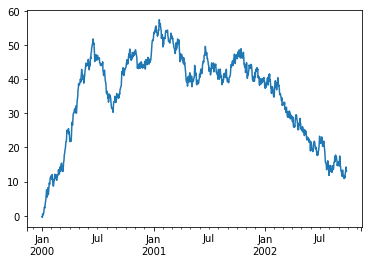

In [ ]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range('1/1/2000', periods=1000))
ts = ts.cumsum()
ts.plot()

对于DataFrame类型，**plot()**能很方便地画出所有列及其标签

In [ ]:
df = pd.DataFrame(np.random.randn(1000, 4), index=ts.index, columns=['A', 'B', 'C', 'D'])
df = df.cumsum()
plt.figure(); df.plot(); plt.legend(loc='best')

NameError: name 'ts' is not defined

# 获取数据的I/O

## CSV

写入一个csv文件

In [ ]:
df.to_csv('data/foo.csv')

从一个csv文件读入

In [ ]:
pd.read_csv('data/foo.csv')

,Unnamed: 0,A,B,C,D
0,2000-01-01,-0.547915,0.758504,-0.791553,-0.014276
1,2000-01-02,-1.478652,-1.824863,0.001416,-1.067864
2,2000-01-03,-3.070727,-1.655967,-0.551411,-2.188238
3,2000-01-04,-3.317105,-1.810778,0.354000,-1.995760
4,2000-01-05,-2.822308,-2.757077,1.210057,-1.250592
5,2000-01-06,-2.223865,-3.256931,3.658672,-1.232510
6,2000-01-07,-0.559411,-2.842820,4.860993,-0.418853
7,2000-01-08,-0.524812,-2.748762,6.280814,0.170616
8,2000-01-09,0.204528,-0.865022,5.560456,0.875871
9,2000-01-10,0.688895,-1.704024,5.226062,0.444483


## HDF5

HDFStores的读写

写入一个HDF5 Store

In [ ]:
df.to_hdf('data/foo.h5', 'df')

从一个HDF5 Store读入

In [ ]:
pd.read_hdf('data/foo.h5', 'df')

,A,B,C,D
2000-01-01,-0.547915,0.758504,-0.791553,-0.014276
2000-01-02,-1.478652,-1.824863,0.001416,-1.067864
2000-01-03,-3.070727,-1.655967,-0.551411,-2.188238
2000-01-04,-3.317105,-1.810778,0.354000,-1.995760
2000-01-05,-2.822308,-2.757077,1.210057,-1.250592
2000-01-06,-2.223865,-3.256931,3.658672,-1.232510
2000-01-07,-0.559411,-2.842820,4.860993,-0.418853
2000-01-08,-0.524812,-2.748762,6.280814,0.170616
2000-01-09,0.204528,-0.865022,5.560456,0.875871
2000-01-10,0.688895,-1.704024,5.226062,0.444483


## Excel

MS Excel的读写

写入一个Excel文件

In [ ]:
df.to_excel('data/foo.xlsx', sheet_name='Sheet1')

从一个excel文件读入

In [ ]:
pd.read_excel('data/foo.xlsx', 'Sheet1', index_col=None, na_values=['NA'])

,A,B,C,D
2000-01-01,-0.547915,0.758504,-0.791553,-0.014276
2000-01-02,-1.478652,-1.824863,0.001416,-1.067864
2000-01-03,-3.070727,-1.655967,-0.551411,-2.188238
2000-01-04,-3.317105,-1.810778,0.354000,-1.995760
2000-01-05,-2.822308,-2.757077,1.210057,-1.250592
2000-01-06,-2.223865,-3.256931,3.658672,-1.232510
2000-01-07,-0.559411,-2.842820,4.860993,-0.418853
2000-01-08,-0.524812,-2.748762,6.280814,0.170616
2000-01-09,0.204528,-0.865022,5.560456,0.875871
2000-01-10,0.688895,-1.704024,5.226062,0.444483
